In [1]:
import os
import sys
import numpy as np
import h5py

sys.path.append('/home/pranavsatheesh/arepo_package/')
import arepo_package as arepo
import BRAHMA_python as il_brahma
import illustris_python as il
from astropy.cosmology import Planck15
import matplotlib.pyplot as plt

In [2]:
sys.path.append('../../py_files/')

import control_sample as control
import host_galaxy_enhancement_plots as hostplot

In [3]:
sys.path.append('/home/pranavsatheesh/host_galaxies/py_files/')
import merger_descendants as md

In [10]:

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop,max_Mstar_tolerance=0.15,max_z_tolerance=0.1)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    if brahma_simName_array[i] == 'SM5_LW10_LOWSPIN_RICH_TNG':
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.6,max_z_tolerance=0.2)
    else:
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.15,max_z_tolerance=0.2)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=12,zbin_width=0.3,min_N_values=10)


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


For TNG50:


finding controls: 100%|██████████| 504/504 [00:01<00:00, 296.59it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:411: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 16
SM5_TNG


finding controls: 100%|██████████| 773/773 [00:00<00:00, 25792.72it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:705: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:709: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:712: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 172
number of processable mergers with valid controls:
581
[31, 40, 44, 65, 68, 83, 62, 39, 25, 13]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 228
number of processable mergers with valid controls:
574
[40, 36, 51, 55, 62, 79, 78, 49, 18, 11]
SM5_LW10_LOWSPIN_TNG


finding controls: 100%|██████████| 488/488 [00:00<00:00, 27045.37it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 123
number of processable mergers with valid controls:
356
[27, 21, 21, 35, 28, 58, 45, 26, 24, 16, 10]
SM5_LW10_LOWSPIN_RICH_TNG


finding controls: 100%|██████████| 175/175 [00:00<00:00, 25783.45it/s]

Number of cases where a close enough match is not found within the acceptable tolerance: 25
number of processable mergers with valid controls:
149
[11, 12, 25, 20, 11, 11, 12, 10]
[55, 56, 54, 63, 65, 55, 68, 51]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 4.5]
Brahma common zbins: [0.  0.2 0.8 1.5 2.2 3.1 4.1 5.1 7.1]


In [11]:
sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

In [4]:
sSFR_sBHAR_evolution_folder = '/home/pranavsatheesh/host_galaxies/data/sSFR_sBHAR_evolution/'
sims = ['SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_RICH_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_TNG','SM5_TNG','TNG50-1']

In [5]:
evolution = {}

for sim in sims:
    evolution_file_name = sSFR_sBHAR_evolution_folder + 'sSFR_sBHAR_evolution_' + sim + '.hdf5'
    if os.path.isfile(evolution_file_name):
        with h5py.File(evolution_file_name, 'r') as f:
            evolution[sim] = {
                'match_ids': f['match_ids'][:],
                'sSFR': f['chains/sSFR'][:],
                'sBHAR': f['chains/sBHAR'][:],
                'time_since_merger': f['chains/time_since_merger'][:],
                'simname': f['chains'].attrs['simname'],
                'sim_type': f['chains'].attrs['sim_type'],
                'num_chains': f['chains'].attrs['num_chains'],
            }
    else:
        print(f"Evolution file for {sim} not found. Skipping.")

In [6]:
evolution['SM5_DFD_3_TNG']['time_since_merger']

array([array([ 0.        ,  0.09240054,  0.21647646,  0.38417847,  0.62949995,
               0.99238624,  1.59703156,  2.73564012,  3.74373748,  5.32847438,
               6.76434741,  8.03662264,  8.83909129,  9.74849029, 10.77223828,
              11.91620277, 13.25254557])                                      ,
       array([ 0.        ,  0.09240054,  0.21647646,  0.38417847,  0.62949995,
               0.99238624,  1.59703156,  2.73564012,  3.74373748,  5.32847438,
               6.76434741,  8.03662264,  8.83909129,  9.74849029, 10.77223828,
              11.91620277, 13.25254557])                                      ,
       array([ 0.        ,  0.12407592,  0.29177794,  0.53709941,  0.89998571,
               1.50463103,  2.64323958,  3.65133694,  5.23607385,  6.67194687,
               7.9442221 ,  8.74669075,  9.65608975, 10.67983774, 11.82380223,
              13.16014503])                                                   ,
       array([ 0.        ,  0.12407592,  0.291777

In [33]:
evolution['SM5_DFD_3_TNG']['sSFR'][3]

array([5.17233620e-09, 5.11712297e-09, 5.67549556e-09, 4.07936509e-09,
       3.59242317e-09, 3.59971836e-09, 1.23387133e-09, 2.40095526e-10,
       6.04339095e-11, 1.42332672e-10, 8.59428715e-11, 6.38173314e-11,
       3.51742044e-11, 3.52525637e-12, 4.66729248e-12, 8.13329285e-13])

Text(0.5, 1.0, ' SM5_DFD_3_TNG')

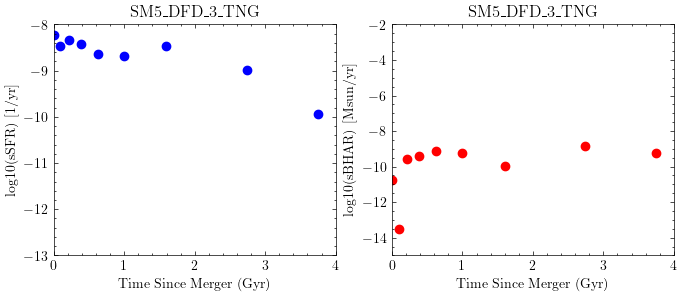

In [8]:
sSFR_vals = evolution['SM5_DFD_3_TNG']['sSFR'][0]
positive_sSFR_indices = np.where(sSFR_vals > 0)[0]
time_since_merger = evolution['SM5_DFD_3_TNG']['time_since_merger'][0][positive_sSFR_indices]
log_sSFR_vals = np.log10(sSFR_vals[positive_sSFR_indices])

sBHAR_vals = evolution['SM5_DFD_3_TNG']['sBHAR'][0]
positive_sBHAR_indices = np.where(sBHAR_vals > 0)[0]
time_since_merger_sBHAR = evolution['SM5_DFD_3_TNG']['time_since_merger'][0][positive_sBHAR_indices]
log_sBHAR_vals = np.log10(sBHAR_vals[positive_sBHAR_indices])

fig,ax = plt.subplots(1,2,figsize=(8,3))

ax[0].scatter(time_since_merger, log_sSFR_vals, marker='o', linestyle='-', color='blue')
ax[0].set_xlabel('Time Since Merger (Gyr)')
ax[0].set_ylabel('log10(sSFR) [1/yr]')
ax[0].set_title(' SM5_DFD_3_TNG')
ax[0].set_xlim(0,4)
ax[0].set_ylim(-13, -8) 

ax[1].scatter(time_since_merger_sBHAR, log_sBHAR_vals, marker='o', linestyle='-', color='red')
ax[1].set_xlabel('Time Since Merger (Gyr)')
ax[1].set_ylabel('log10(sBHAR) [Msun/yr]')
ax[1].set_xlim(0,4)
ax[1].set_ylim(-15, -2)
ax[1].set_title(' SM5_DFD_3_TNG')
# ax[1].set_title('Evolution of sBHAR with Time Since Merger for SM5_DFD_3_TNG')

In [67]:
basePath = "/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_DFD_3_TNG/"
descendant_file_loc = '/home/pranavsatheesh/host_galaxies/data/descendant_files/'
simName = basePath.split('/')[-2]
minN_values = [0, 0, 10, 1]  # gas, dm, star, bh
descendant_file_name = f'merger_descendants_{simName}.hdf5'
descendant_file_path = os.path.join(descendant_file_loc, descendant_file_name)
print(f'Opening: {descendant_file_path}')
descendant_file = h5py.File(descendant_file_path, 'r')
print(f'File keys: {list(descendant_file.keys())}')

Opening: /home/pranavsatheesh/host_galaxies/data/descendant_files/merger_descendants_SM5_DFD_3_TNG.hdf5
File keys: ['descendants', 'fp_snap', 'fp_subfind', 'merger_idx', 'pm_snap', 'pm_subfind']


In [5]:
pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'
simPath = basePath
pop = control.load_pop_file(simPath, pop_file_path,minN_values)
pop_control = control.control_sample_brahma(pop)
zbins = hostplot.find_adaptive_z_bins(pop_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.2,min_N_values=10)

finding controls:   0%|          | 0/1178 [00:00<?, ?it/s]

finding controls: 100%|██████████| 1178/1178 [00:00<00:00, 21219.84it/s]

Number of cases where a close enough match is not found within the acceptable tolerance: 335
number of processable mergers with valid controls:
839
[38, 43, 45, 67, 97, 76, 110, 78, 48, 30, 11]



/home/pranavsatheesh/host_galaxies/notebooks/../py_files/control_sample.py:667: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/../py_files/control_sample.py:671: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/../py_files/control_sample.py:674: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


In [6]:
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_descendant_file_name = f'merger_descendants_TNG50-1.hdf5'
TNG_descendant_file_path = os.path.join(descendant_file_loc, TNG_descendant_file_name)
print(f'Opening: {TNG_descendant_file_path}')
TNG_descendant_file = h5py.File(TNG_descendant_file_path, 'r')
print(f'File keys: {list(TNG_descendant_file.keys())}')

Opening: /home/pranavsatheesh/host_galaxies/data/descendant_files/merger_descendants_TNG50-1.hdf5
File keys: ['descendants', 'fp_snap', 'fp_subfind', 'merger_idx', 'pm_snap', 'pm_subfind']


In [7]:
TNG_50_pop = control.load_pop_file(TNG_basepath,pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)

processing each merger redshifts for controls:   0%|          | 0/83 [00:00<?, ?it/s]

processing each merger redshifts for controls: 100%|██████████| 83/83 [00:01<00:00, 42.58it/s]
/home/pranavsatheesh/host_galaxies/notebooks/../py_files/control_sample.py:378: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14


In [8]:
counter = 0
store_matches = []

fields=['SubhaloMassType','SubhaloMass', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloSFR']


for i in range(len(pop_control.valid_merger_indices)):
    post_merger_snap = pop_control.snap_merging_pop[i] 
    post_merger_id = pop_control.subhalo_ids_mergers[i]

    match_idx = np.argwhere(
        (descendant_file['pm_snap'][:] == post_merger_snap) &
        (descendant_file['pm_subfind'][:] == post_merger_id)
    )
    counter += 1
    store_matches.append(match_idx[0])

    #the control sSFR is 
    #pop_control.sSFR_control_pop[i]

        # print(f'Match indices: {match_idx}')
print(f'Number of matches found: {counter} out of {len(descendant_file["merger_idx"][:])}')

Number of matches found: 648 out of 1178


In [30]:
counter = 0
store_matches = []

fields=['SubhaloMassType','SubhaloMass', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloSFR']


for i in range(len(TNG_50_control.valid_merger_indices)):
    post_merger_snap = TNG_50_control.snap_merging_pop[i] 
    post_merger_id = TNG_50_control.subhalo_ids_mergers[i]

    match_idx = np.argwhere(
        (TNG_descendant_file['pm_snap'][:] == post_merger_snap) &
        (TNG_descendant_file['pm_subfind'][:] == post_merger_id)
    )
    counter += 1
    store_matches.append(match_idx[0])

    #the control sSFR is 
    #TNG_50_control.sSFR_control_pop[i]

        # print(f'Match indices: {match_idx}')
print(f'Number of matches found: {counter} out of {len(TNG_descendant_file["merger_idx"][:])}')

Number of matches found: 472 out of 504


In [19]:
def z_to_tlookback(z):
    """Convert redshift to lookback time in Gyr using Planck15 cosmology."""
    return Planck15.lookback_time(z).value  # returns time in Gyr

In [20]:
brahma_snapshots,brahma_redshifts = arepo.get_snapshot_redshift_correspondence(basePath)

In [24]:
def get_scale_factors(basePath, filename="output_scale_factors.txt"):
    path = basePath.split('/output')[0]
    #print(path)
    f = open(path+"/"+filename,'r')
    snaptimes = np.array([float(line) for line in f.readlines()])
    f.close()
    print(f"snapshot scale factors in {path}:")
    return snaptimes

TNG_scalefactors = get_scale_factors(TNG_basepath)
TNG_redshifts = 1/TNG_scalefactors - 1                  
TNG_snapshots = np.arange(len(TNG_scalefactors))

snapshot scale factors in /orange/lblecha/IllustrisTNG/Runs/TNG50-1:


In [25]:
def find_deltaT(z1,z2):
    """Calculate the difference in lookback time between two redshifts."""
    t1 = z_to_tlookback(z1)
    t2 = z_to_tlookback(z2)
    return t1 - t2  # returns time difference in Gyr

In [27]:
def find_most_massive_BHAR(snap, subfind_id,key="BRAHMA"):

    if key=="BRAHMA":
        redshift = brahma_redshifts[snap]
        MBH_masses_in_subhalo = arepo.get_particle_property_within_postprocessed_groups(basePath,particle_property=['BH_Mass'],p_type=5,desired_redshift=redshift,subhalo_index=subfind_id,group_type='subhalo')
        Mdot_in_subhalo = arepo.get_particle_property_within_postprocessed_groups(basePath,particle_property=['BH_Mdot'],p_type=5,desired_redshift=redshift,subhalo_index=subfind_id,group_type='subhalo')
        MBH_most_massive_BH = np.max(MBH_masses_in_subhalo[0])
        index_of_most_massive_BH = np.argmax(MBH_masses_in_subhalo[0])

    else:
        print("TNG doesn't require this function")

    return MBH_most_massive_BH, Mdot_in_subhalo[0][index_of_most_massive_BH]        

In [34]:
h = 0.6774

In [36]:
descendant_chain_length = len(TNG_descendant_file['descendants']['snaps'][87])
snap_0 = TNG_descendant_file['descendants']['snaps'][87][0]
TNG_redshift_0 = TNG_redshifts[snap_0]

sSFR_descendant_chain = np.zeros(descendant_chain_length)
sBHAR_descendant_chain = np.zeros(descendant_chain_length)
time_since_merger_chain = np.zeros(descendant_chain_length)

for i in range(descendant_chain_length):
    snap_i = TNG_descendant_file['descendants']['snaps'][87][i]
    subhalo_id_i = TNG_descendant_file['descendants']['subfind_ids'][87][i]
    TNG_redshifts_i = TNG_redshifts[snap_i]
    time_since_merger = find_deltaT(TNG_redshift_0, TNG_redshifts_i)
    time_since_merger_chain[i] = time_since_merger
    print(snap_i,subhalo_id_i)
    subhalos = il.groupcat.loadSubhalos(TNG_basepath, snap_i, fields=fields)
    SFR_i = subhalos['SubhaloSFR'][subhalo_id_i]   
    Mstar_i = subhalos['SubhaloMassType'][subhalo_id_i,4] * 1e10 / h

    sSFR_i = SFR_i / Mstar_i if Mstar_i > 0 else 0
    sSFR_descendant_chain[i] = sSFR_i

    Mdot_i = subhalos['SubhaloBHMdot'][subhalo_id_i]*1e10/h/(0.978e9/h) #convert to Msun/yr
    MBH_i = subhalos['SubhaloBHMass'][subhalo_id_i] * 1e10 / h #convert to Msun
    sBHAR_i = Mdot_i / MBH_i if MBH_i > 0 else 0
    sBHAR_descendant_chain[i] = sBHAR_i


98 118173
99 117251


In [ ]:
descendant_chain_length = len(descendant_file['descendants']['snaps'][86])
sSFR_descendant_chain = np.zeros(descendant_chain_length)
sBHAR_descendant_chain = np.zeros(descendant_chain_length)
time_since_merger_chain = np.zeros(descendant_chain_length)
snap_0 = descendant_file['descendants']['snaps'][86][0]
redshift_0 = brahma_redshifts[snap_0]
for i in range(descendant_chain_length):
    snap_i = descendant_file['descendants']['snaps'][86][i]
    subhalo_id_i = descendant_file['descendants']['subfind_ids'][86][i]
    redshift_i = brahma_redshifts[snap_i]
    time_since_merger = find_deltaT(redshift_0, redshift_i)
    time_since_merger_chain[i] = time_since_merger
    print(snap_i,subhalo_id_i)
    subhalos = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snap_i,fields)
    SFR_i = subhalos['SubhaloSFR'][subhalo_id_i]
    Mstar_i = subhalos['SubhaloMassType'][subhalo_id_i,4]*1e10/h

    sSFR_i = SFR_i/(Mstar_i)
    sSFR_descendant_chain[i] = sSFR_i

    MBH_most_massive_BH, Mdot_most_massive_BH = find_most_massive_BHAR(snap_i, subhalo_id_i)   
    MBH_most_massive_BH = MBH_most_massive_BH*1e10/h #convert to Msun
    Mdot_most_massive_BH = Mdot_most_massive_BH*1e10/h/(0.978e9/h) #convert to Msun/yr

    sBHAR_most_massive_BH = Mdot_most_massive_BH/MBH_most_massive_BH
    sBHAR_descendant_chain[i] = sBHAR_most_massive_BH
    #MBH_massive,Mdot_massive = self.get_most_massive_n_luminous_BH_in_subhalo(redshift,subhalo_ids_merging,NBHs)

In [ ]:
time_since_merger_chain

In [ ]:
pop_control.sSFR_control_pop[0]

In [ ]:
pop_control.sSFR_merging_pop[0]

In [ ]:
descendant_file['descendants']['snaps'][86]

In [ ]:
values, counts = np.unique(store_matches, return_counts=True)
duplicates = values[counts > 1]
print(f'Indices in control sample that matched more than once: {duplicates}')
print(len(duplicates))

In [ ]:
descendant_file['descendants'].keys()

In [ ]:
descendant_file['descendants']['snaps'][1]

In [ ]:
descendant_file['descendants']['subfind_ids'][1]

In [ ]:
descendant_file['fp_snap'][1]

In [ ]:

descendant_file_loc = '/home/pranavsatheesh/host_galaxies/data/'
simName = basePath.split('/')[-2]
minN_values = [0, 0, 10, 1]  # gas, dm, star, bh

sim_type = 'TNG' if 'TNG50' in simName else 'BRAHMA'
merger_file_folder = '/home/pranavsatheesh/host_galaxies/data/merger_files/'
    # Load merger file
mrgrfile = md.load_merger_file(merger_file_folder, simName, minN_values)
shids_subf = mrgrfile['shids_subf'][:]
snaps = mrgrfile['snaps'][:]

In [ ]:
full_tree = None
if sim_type == 'BRAHMA':
    print(f"Loading BRAHMA tree...")
    tree = h5py.File(basePath + 'postprocessing/tree_extended.hdf5', 'r')
    full_tree = {key: tree[key][:] for key in tree.keys()}
    tree.close()
    print(f"Loaded {len(full_tree)} fields from tree")

In [ ]:
n = len(shids_subf)
merger_idx  = np.empty(n, dtype=np.int32)
fp_subfind  = np.empty(n, dtype=np.int32)
fp_snap     = np.empty(n, dtype=np.int32)
desc_list   = []  # still a list since variable-length

valid_mask = []

for idx in range(n):
    fp_subf = int(shids_subf[idx][0])
    fp_snap_val = int(snaps[idx][0])
    
    descendants = md.get_merger_descendants_BRAHMA(full_tree, fp_subf, fp_snap_val)
    
    if descendants is not None:
        merger_idx[idx] = idx
        fp_subfind[idx] = fp_subf
        fp_snap[idx]    = fp_snap_val
        desc_list.append(descendants)
        valid_mask.append(idx)

    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{n} mergers")

# Trim to valid entries
valid_mask = np.array(valid_mask)
merger_idx = merger_idx[valid_mask]
fp_subfind = fp_subfind[valid_mask]
fp_snap    = fp_snap[valid_mask]

In [ ]:
vlen_float = h5py.vlen_dtype(np.float64)
vlen_int   = h5py.vlen_dtype(np.int32)

with h5py.File("test_merger_descendants.hdf5", "w") as f:
    # Scalar fields - these are just numpy arrays so easy
    f.create_dataset("merger_idx", data=merger_idx, dtype=np.int32)
    f.create_dataset("fp_subfind", data=fp_subfind, dtype=np.int32)
    f.create_dataset("fp_snap",    data=fp_snap,    dtype=np.int32)
    
    # Variable-length descendant arrays
    grp = f.create_group("descendants")
    n = len(desc_list)
    
    ds_ids  = grp.create_dataset("subfind_ids",   (n,), dtype=vlen_int)
    ds_snps = grp.create_dataset("snaps",         (n,), dtype=vlen_int)
    ds_npk  = grp.create_dataset("next_prog_key", (n,), dtype=vlen_int)
    
    for i, desc in enumerate(desc_list):
        ds_ids[i]  = desc["subfind_ids"]
        ds_snps[i] = desc["snaps"]
        ds_npk[i]  = desc["next_prog_key"]


In [ ]:
with h5py.File("test_merger_descendants.hdf5", "r") as f:
    # Scalar fields - load all at once into numpy arrays
    merger_idx = f["merger_idx"][:]
    fp_subfind = f["fp_subfind"][:]
    fp_snap    = f["fp_snap"][:]
    
    # Variable-length fields - loads as a numpy array of objects
    subfind_ids   = f["descendants/subfind_ids"][:]
    snaps         = f["descendants/snaps"][:]
    next_prog_key = f["descendants/next_prog_key"][:]

In [ ]:
fp_subfind[2]

In [ ]:
next_prog_key[2]

In [ ]:
subfind_ids[2]

In [ ]:

descendant_file_loc = '/home/pranavsatheesh/host_galaxies/data/'
simName = basePath.split('/')[-2]
minN_values = [0, 0, 10, 1]  # gas, dm, star, bh
descendant_file_name = f'merger_descendants_{simName}.hdf5'
descendant_file_path = os.path.join(descendant_file_loc, descendant_file_name)
print(f'Opening: {descendant_file_path}')
descendant_file = h5py.File(descendant_file_path, 'r')
print(f'File keys: {list(descendant_file.keys())}')
if 'mergers' in descendant_file:
    mergers = descendant_file['mergers']
    merger_keys = list(mergers.keys())
    print(f'Total mergers: {len(merger_keys)}')
    print(f'First merger: {merger_keys[0]}')

In [ ]:
print("Mergers group attributes:")
print(dict(mergers.attrs))
print("\nMerger keys (first 10):")
merger_keys = list(mergers.keys())
for key in merger_keys[:10]:
    print(f"  {key}")
print(f"... (total {len(merger_keys)} mergers)")

In [ ]:
mergers['merger_000000']['snaps'][:]

In [ ]:
merger_file_path = '/home/pranavsatheesh/host_galaxies/data/merger_files' + merger_file_name
demo_idx = 0  # choose which merger row to inspect

with h5py.File(merger_file_path, 'r') as mf:
    shids_subf = mf['shids_subf'][:]   # columns: [first_prog, next_prog, descendant]
    snaps = mf['snaps'][:]             # columns: [fp_snap, np_snap, desc_snap]
    prog_mass_ratio = mf['ProgMassRatio'][:] if 'ProgMassRatio' in mf else None

nmergers = len(shids_subf)
print(f'Total mergers in file: {nmergers}')

if nmergers == 0:
    print('No mergers in this file.')
else:
    if demo_idx < 0 or demo_idx >= nmergers:
        raise IndexError(f'demo_idx={demo_idx} out of range [0, {nmergers-1}]')

    fp_subf, np_subf, desc_subf = shids_subf[demo_idx]
    fp_snap, np_snap, desc_snap = snaps[demo_idx]

    print('One merger demo:')
    print(f'  index = {demo_idx}')
    print(f'  First progenitor: SubfindID={int(fp_subf)}, Snap={int(fp_snap)}')
    print(f'  Next progenitor : SubfindID={int(np_subf)}, Snap={int(np_snap)}')
    print(f'  Descendant      : SubfindID={int(desc_subf)}, Snap={int(desc_snap)}')
    if prog_mass_ratio is not None:
        print(f'  ProgMassRatio   : {float(prog_mass_ratio[demo_idx]):.4g}')

In [ ]:
# Walk down the descendant branch starting from the demo merger remnant.
# Requires: full_tree loaded, and desc_subf/desc_snap defined from Cell 16.


def build_snap_subfind_index(full_tree):
    """Map (SnapNum, SubfindID) -> tree index for fast lookup."""
    lookup = {}
    for i in range(len(full_tree['SnapNum'])):
        key = (int(full_tree['SnapNum'][i]), int(full_tree['SubfindID'][i]))
        # Keep first occurrence if duplicates appear.
        if key not in lookup:
            lookup[key] = i
    return lookup

def walk_descendant_chain(full_tree, start_idx):
    """Return list of descendant nodes from start_idx until DescendantID == -1."""
    chain = []
    root_subhalo_id = int(full_tree['SubhaloID'][0])

    cur_idx = int(start_idx)
    visited = set()

    while True:
        if cur_idx in visited:
            print('Loop detected in tree traversal. Stopping early.')
            break
        visited.add(cur_idx)

        node = {
            'idx': cur_idx,
            'snap': int(full_tree['SnapNum'][cur_idx]),
            'subfind': int(full_tree['SubfindID'][cur_idx]),
            'subhalo_id': int(full_tree['SubhaloID'][cur_idx]),
            'desc_id': int(full_tree['DescendantID'][cur_idx]),
        }
        chain.append(node)

        desc_id = node['desc_id']
        if desc_id == -1:
            break

        next_idx = desc_id - root_subhalo_id
        if next_idx < 0 or next_idx >= len(full_tree['SubhaloID']):
            print(f'Next descendant index out of bounds: {next_idx}. Stopping early.')
            break

        cur_idx = int(next_idx)

    return chain

# 1) Find tree index for merger remnant from Cell 16
if 'desc_subf' not in locals() or 'desc_snap' not in locals():
    raise RuntimeError('Run Cell 16 first so desc_subf and desc_snap are defined.')

snap_subfind_to_idx = build_snap_subfind_index(full_tree)
start_key = (int(desc_snap), int(desc_subf))
start_idx = snap_subfind_to_idx.get(start_key, None)

if start_idx is None:
    print('Could not find (desc_snap, desc_subf) in current full_tree.')
    print(f'  requested key = {start_key}')
    print('This usually means the merger file and loaded tree are from different simulations.')
else:
    desc_chain = walk_descendant_chain(full_tree, start_idx)
    print(f'Descendant chain length (including start node): {len(desc_chain)}')
    print('snap, subfind, subhalo_id, desc_id')
    for row in desc_chain:
        print(row['snap'], row['subfind'], row['subhalo_id'], row['desc_id'])

In [ ]:
# Find a merger whose remnant has descendants at later snapshots.
# This avoids cases where demo_idx points to a terminal descendant (chain length = 1).

if 'shids_subf' not in locals() or 'snaps' not in locals():
    raise RuntimeError('Run Cell 16 first so shids_subf and snaps are loaded.')
if 'full_tree' not in locals():
    raise RuntimeError('Run Cell 11 first so full_tree is loaded.')

snap_subfind_to_idx = build_snap_subfind_index(full_tree)
root_subhalo_id = int(full_tree['SubhaloID'][0])

found_idx = None
found_chain = None
max_to_check = min(len(shids_subf), 5000)  # scan first N mergers for a non-terminal remnant

for k in range(max_to_check):
    rem_subf = int(shids_subf[k, 2])
    rem_snap = int(snaps[k, 2])
    idx0 = snap_subfind_to_idx.get((rem_snap, rem_subf), None)
    if idx0 is None:
        continue

    desc_id0 = int(full_tree['DescendantID'][idx0])
    if desc_id0 == -1:
        continue

    chain = walk_descendant_chain(full_tree, idx0)
    if len(chain) > 1:
        found_idx = k
        found_chain = chain
        break

if found_idx is None:
    print('No merger with descendants at later snaps found in scanned subset.')
    print('Possible causes:')
    print('  1) Merger file and loaded tree are from different simulations')
    print('  2) Most remnants in this subset are already terminal')
    print('  3) Need to increase max_to_check')
else:
    print(f'Found merger index with later descendants: {found_idx}')
    print('First 10 nodes in descendant chain:')
    print('snap, subfind, subhalo_id, desc_id')
    for row in found_chain[:10]:
        print(row['snap'], row['subfind'], row['subhalo_id'], row['desc_id'])

    # Save selection so next cells can reuse this specific merger.
    demo_idx = found_idx
    fp_subf, np_subf, desc_subf = shids_subf[demo_idx]
    fp_snap, np_snap, desc_snap = snaps[demo_idx]
    print('Updated demo_idx to a non-terminal merger remnant.')
    print(f'demo_idx={demo_idx}, remnant=(snap={int(desc_snap)}, subfind={int(desc_subf)})')

In [ ]:
# Simple logic for one merger remnant:
# 1. Walk down the descendant tree and record info at each snap.
# 2. Record whether there is another merger at that node.


def trace_descendants_and_mergers(full_tree, start_snap, start_subfind):
    snap_subfind_to_idx = build_snap_subfind_index(full_tree)
    start_idx = snap_subfind_to_idx.get((int(start_snap), int(start_subfind)), None)
    if start_idx is None:
        print('Could not find starting remnant in full_tree.')
        return []

    records = []
    root_subhalo_id = int(full_tree['SubhaloID'][0])
    cur_idx = int(start_idx)
    visited = set()

    while True:
        if cur_idx in visited:
            print('Loop detected, stopping.')
            break
        visited.add(cur_idx)

        next_prog_id = int(full_tree['NextProgenitorID'][cur_idx])
        has_merger = next_prog_id != -1

        incoming_snap = -1
        incoming_subfind = -1
        if has_merger:
            incoming_idx = next_prog_id - root_subhalo_id
            if 0 <= incoming_idx < len(full_tree['SubhaloID']):
                incoming_snap = int(full_tree['SnapNum'][incoming_idx])
                incoming_subfind = int(full_tree['SubfindID'][incoming_idx])

        records.append({
            'snap': int(full_tree['SnapNum'][cur_idx]),
            'subfind': int(full_tree['SubfindID'][cur_idx]),
            'subhalo_id': int(full_tree['SubhaloID'][cur_idx]),
            'has_merger': has_merger,
            'incoming_snap': incoming_snap,
            'incoming_subfind': incoming_subfind,
        })

        desc_id = int(full_tree['DescendantID'][cur_idx])
        if desc_id == -1:
            break

        next_idx = desc_id - root_subhalo_id
        if next_idx < 0 or next_idx >= len(full_tree['SubhaloID']):
            print('Descendant index out of bounds, stopping.')
            break

        cur_idx = int(next_idx)

    return records

# Use the merger remnant from Cell 16 or the updated one from Cell 18.
desc_records = trace_descendants_and_mergers(full_tree, desc_snap, desc_subf)

print('snap, subfind, subhalo_id, has_merger, incoming_snap, incoming_subfind')
for row in desc_records:
    print(
        row['snap'], row['subfind'], row['subhalo_id'],
        row['has_merger'], row['incoming_snap'], row['incoming_subfind']
    )

In [ ]:
print("Merger chain lengths and indices:")
print("merger_idx | chain_length")
print("-" * 25)
for key in list(mergers.keys())[:20]:
    merger_group = mergers[key]
    merger_idx = merger_group.attrs['merger_idx']
    chain_length = merger_group.attrs['chain_length']
    print(f"{merger_idx:9d} | {chain_length:12d}")

# Show statistics
all_chain_lengths = [mergers[key].attrs['chain_length'] for key in mergers.keys()]
print(f"\nChain length statistics:")
print(f"  Min: {np.min(all_chain_lengths)}")
print(f"  Max: {np.max(all_chain_lengths)}")
print(f"  Mean: {np.mean(all_chain_lengths):.2f}")
print(f"  Median: {np.median(all_chain_lengths):.2f}")